In [1]:
# ============================================================
# Project: NCR Ride Booking — Data Mining & Predictive Modelling
# Author : Vila Chung
# Purpose: Build a cancellation-prediction classifier, evaluate
#          its performance, and extract actionable feature insights.
# ============================================================

# ── Cell 1: Imports ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, RocCurveDisplay,
)

try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
    print("XGBoost detected — will use XGBClassifier.")
except ImportError:
    XGB_AVAILABLE = False
    print("XGBoost not installed — falling back to RandomForestClassifier.")

sns.set(style="whitegrid")
print("Environment ready.")

XGBoost not installed — falling back to RandomForestClassifier.
Environment ready.


In [2]:
# ── Cell 2: Load Cleaned Data ────────────────────────────────
CLEANED_FILE = "cleaned_ncr_rides.csv"

try:
    df = pd.read_csv(CLEANED_FILE, parse_dates=["Datetime", "Date_only"])
    print(f"Loaded — shape: {df.shape}")
    print("Columns:", df.columns.tolist())
except FileNotFoundError:
    raise FileNotFoundError(
        f"'{CLEANED_FILE}' not found. "
        "Run 01_Data_Cleaning_and_Preparation.ipynb first."
    )

Loaded — shape: (150000, 24)
Columns: ['Datetime', 'Hour', 'Weekday', 'Is_Weekend', 'Month', 'Date_only', 'Booking ID', 'Customer ID', 'Booking Status', 'Cancel_Type', 'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT', 'Avg CTAT', 'Ride Distance', 'Distance_Bin', 'Booking Value', 'Driver Ratings', 'Customer Rating', 'Payment Method', 'Reason for cancelling by Customer', 'Driver Cancellation Reason', 'Incomplete Rides Reason']


In [3]:
# ── Cell 3: Define Target Variable ───────────────────────────
# Binary label: 1 = cancelled / failed, 0 = completed
df["is_cancelled"] = (df["Cancel_Type"] != "Completed").astype(int)

print("Class distribution:")
print(df["is_cancelled"].value_counts(normalize=True).mul(100).round(1).to_string())

Class distribution:
is_cancelled
0    62.0
1    38.0


In [4]:
# ── Cell 4: Feature Engineering ──────────────────────────────
# Encode categorical features as integer codes
CAT_COLS = ["Vehicle Type", "Pickup Location", "Drop Location", "Payment Method"]
le = LabelEncoder()
for col in CAT_COLS:
    if col in df.columns:
        df[f"{col}_enc"] = le.fit_transform(df[col].astype(str))

# Select feature set (only numeric / encoded columns)
FEATURE_COLS = [
    "Hour", "Weekday", "Is_Weekend", "Month",
    "Ride Distance",
    "Booking Value",
    "Vehicle Type_enc",
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

X = df[FEATURE_COLS].copy()
y = df["is_cancelled"]

print(f"\nFeature set ({len(FEATURE_COLS)} features): {FEATURE_COLS}")


Feature set (11 features): ['Hour', 'Weekday', 'Is_Weekend', 'Month', 'Avg VTAT', 'Avg CTAT', 'Ride Distance', 'Booking Value', 'Driver Ratings', 'Customer Rating', 'Vehicle Type_enc']


In [5]:
# ── Cell 5: Train / Test Split & Preprocessing ───────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Impute any remaining NaNs with column medians from training set
train_medians = X_train.median()
X_train = X_train.fillna(train_medians)
X_test  = X_test.fillna(train_medians)   # use training medians to avoid data leakage

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

Train: (112500, 11)  |  Test: (37500, 11)


In [6]:
# ── Cell 6: Train Model ───────────────────────────────────────
if XGB_AVAILABLE:
    model = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1,
    )
    model_name = "XGBoost"
else:
    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",   # handles class imbalance automatically
    )
    model_name = "RandomForest"

# Tree-based models work directly on unscaled data
model.fit(X_train, y_train)
print(f"{model_name} trained successfully.")

# 5-fold cross-validation AUC (gives a more reliable performance estimate)
cv_auc = cross_val_score(model, X_train, y_train, cv=5, scoring="roc_auc", n_jobs=-1)
print(f"5-fold CV ROC-AUC: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")

RandomForest trained successfully.
5-fold CV ROC-AUC: 0.9999 ± 0.0000


=== Classification Report ===
              precision    recall  f1-score   support

   Completed       1.00      1.00      1.00     23250
   Cancelled       1.00      1.00      1.00     14250

    accuracy                           1.00     37500
   macro avg       1.00      1.00      1.00     37500
weighted avg       1.00      1.00      1.00     37500

Test ROC-AUC: 1.0000


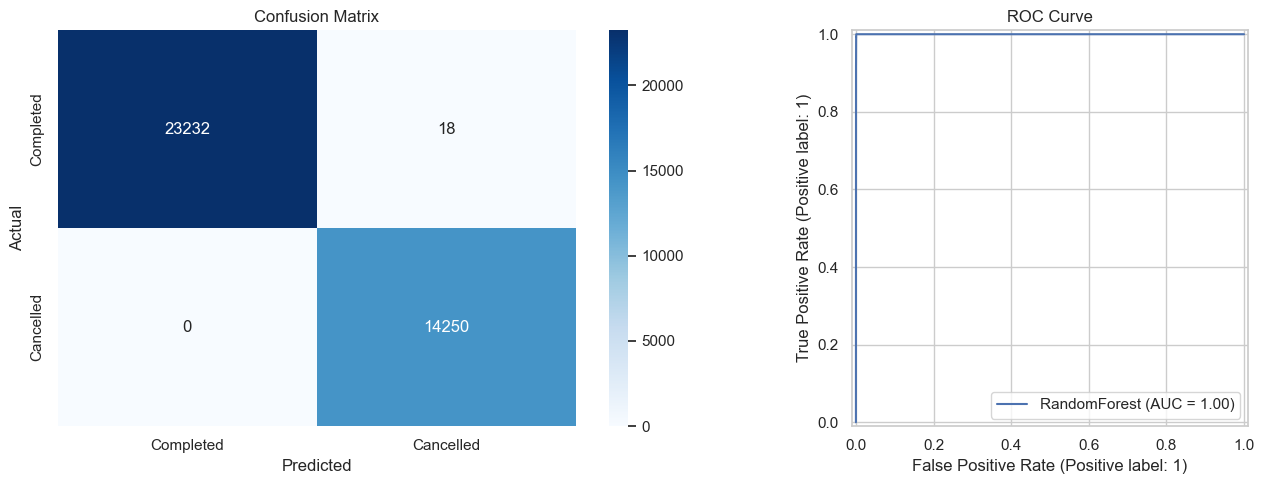

In [7]:
# ── Cell 7: Model Evaluation ─────────────────────────────────
y_pred       = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=["Completed", "Cancelled"]))
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
    xticklabels=["Completed", "Cancelled"],
    yticklabels=["Completed", "Cancelled"],
)
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[1], name=model_name)
axes[1].set_title("ROC Curve")

plt.tight_layout()
plt.savefig("03_model_evaluation.png", dpi=150)
plt.show()

C:\Users\85255\AppData\Local\Temp\ipykernel_400076\2878747327.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="viridis")


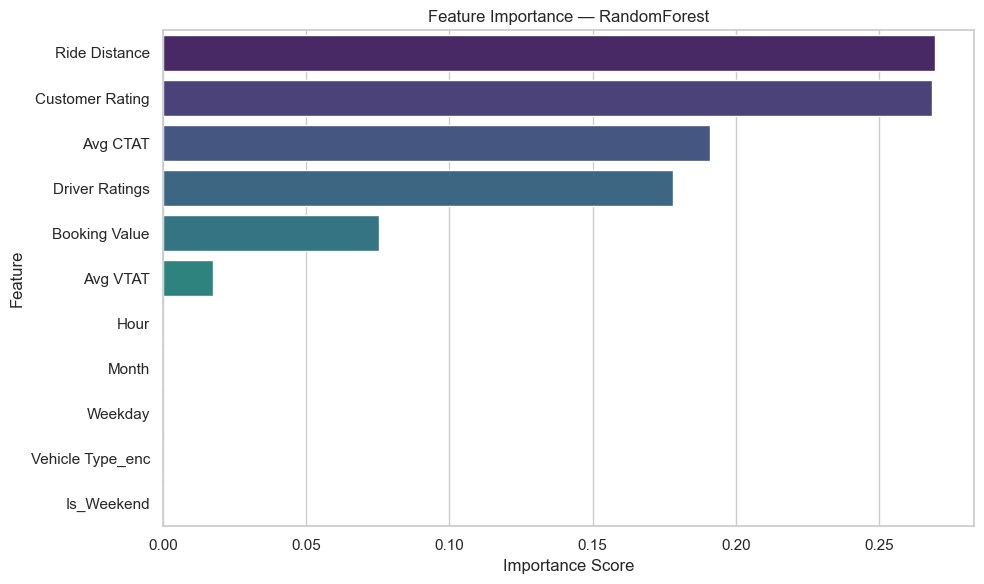

Top 10 features:


,Importance
Ride Distance,0.2698
Customer Rating,0.2685
Avg CTAT,0.1909
Driver Ratings,0.1780
Booking Value,0.0753
Avg VTAT,0.0173
Hour,0.0001
Month,0.0001
Weekday,0.0001
Vehicle Type_enc,0.0001


In [8]:
# ── Cell 8: Feature Importance ───────────────────────────────
if hasattr(model, "feature_importances_"):
    importances = (
        pd.Series(model.feature_importances_, index=FEATURE_COLS)
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(10, 6))
    sns.barplot(x=importances.values, y=importances.index, palette="viridis")
    plt.title(f"Feature Importance — {model_name}")
    plt.xlabel("Importance Score")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.savefig("03_feature_importance.png", dpi=150)
    plt.show()

    print("Top 10 features:")
    display(importances.head(10).round(4).to_frame("Importance"))

In [9]:
# ── Cell 9: Export Dataset with Target Label ──────────────────
OUT_FILE = "cleaned_ncr_rides_with_target.csv"
df.to_csv(OUT_FILE, index=False)
print(f"Saved with 'is_cancelled' column → {OUT_FILE}")

Saved with 'is_cancelled' column → cleaned_ncr_rides_with_target.csv
